# E1 — Stress test: GRU vs LSTM vs Transformer

One seed, no early stopping. The point is to see where each validation curve peaks so the team
can fix one training budget for the 3-seed runs. These numbers pick a budget; they are not the
model-comparison result.

## 1 · Environment

In [1]:
import torch
if not torch.cuda.is_available():
    raise SystemExit("No GPU. Runtime > Change runtime type > GPU, then rerun. CPU would take days.")
print("GPU:", torch.cuda.get_device_name(0))
print("torch:", torch.__version__)


GPU: Tesla T4
torch: 2.11.0+cu130


In [2]:
import os, subprocess, sys
from pathlib import Path

# Guarded: cloning onto an existing directory exits non-zero and check=True would crash.
if not Path('/content/repo/.git').exists():
    subprocess.run([
        "git", "clone", "-q", "-b", "training-refactor",
        "https://github.com/RayYouDS/cits4012-NLP-project.git", "/content/repo"
    ], check=True)
os.chdir('/content/repo')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'sentencepiece'], check=True)

# run_m3.py resolves everything relative to the repo root, so fail here rather than three
# cells later with a confusing path error.
for required in ["scripts/training/run_m3.py", "config/m3_params.json",
                 "scripts/tokenizer/piqa_bpe_v3.model", "datasets/PIQA/train.jsonl"]:
    if not Path(required).is_file():
        raise SystemExit(f"{required} missing — clone failed or the branch moved.")
COMMIT = subprocess.check_output(['git', 'rev-parse', 'HEAD'], text=True).strip()
print('repository commit:', COMMIT)


repository commit: 3905cdb640143e11c827221617aff6ee8e08f013


## 2 · results

 a run's weights and history are saved only
once it finishes. A disconnect mid-run loses that run, and there is no resume. Drive does not
prevent that, but it keeps the runs that already finished.

In [6]:
USE_DRIVE = False                  # False -> results live in /content and die with the runtime
SMOKE_TEST = False                # True -> 3 epochs per run, just to check the pipeline
RUN_LABEL = "e1_smoke" if SMOKE_TEST else "e1_full"

from pathlib import Path
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = Path('/content/drive/MyDrive/cits4012') / RUN_LABEL
else:
    OUT_DIR = Path('/content') / RUN_LABEL

# run_m3.py never clears output_dir, so reusing one mixes two experiments' CSVs.
if OUT_DIR.exists() and any(OUT_DIR.iterdir()):
    raise SystemExit(f"{OUT_DIR} is not empty. Change RUN_LABEL.")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("results ->", OUT_DIR)


results -> /content/e1_full


## 3 · Configuration

Everything comes from the committed `config/m3_params.json`; only the output path and the epoch
settings are overridden. The result is written to `/content/`, not into the repository.

In [8]:
import json, shutil

MAX_EPOCHS = 1000         # the plan's ceiling for the stress test
PATIENCE   = None         # no early stopping, per the plan's E1 exception

with open('config/m3_params.json', encoding='utf-8') as f:
    cfg = json.load(f)
cfg['output_dir'] = str(OUT_DIR)
cfg['max_epochs'] = 3 if SMOKE_TEST else MAX_EPOCHS
cfg['patience']   = PATIENCE

CONFIG_PATH = '/content/e1_config.json'
with open(CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(cfg, f, indent=2)

shutil.copy(CONFIG_PATH, OUT_DIR / 'e1_config.json')   # keep it with the results

n_runs = len(cfg['models']) * len(cfg['learning_rates']) * len(cfg['seeds'])
print(json.dumps(cfg, indent=2))
print(f"\n{len(cfg['models'])} models x {len(cfg['learning_rates'])} lrs x "
      f"{len(cfg['seeds'])} seed = {n_runs} runs x {cfg['max_epochs']} epochs")

{
  "output_dir": "/content/e1_full",
  "tokenizer": "scripts/tokenizer/piqa_bpe_v3.model",
  "models": [
    "transformer",
    "gru",
    "lstm"
  ],
  "learning_rates": [
    0.001,
    0.0003
  ],
  "seeds": [
    4012
  ],
  "optimizer": "adam",
  "weight_decay": null,
  "momentum": 0.9,
  "batch_size": 256,
  "max_epochs": 1000,
  "patience": null,
  "grad_clip": null,
  "num_workers": 2,
  "embedding_dim": 100,
  "hidden_size": 100,
  "bidirectional": true,
  "enable_attention": true,
  "num_heads": 4,
  "num_layers": 3
}

3 models x 2 lrs x 1 seed = 6 runs x 1000 epochs


## 4 · Run

Started as a module from the repo root — `run_m3.py` uses absolute package imports.

Each run writes its `*_history.csv`, `*_val_predictions.csv` and `*_best.pt` as soon as it
finishes. The summary, curves and McNemar test come only after all six.

In [14]:
# -u, and reading the pipe line by line, so the per-epoch lines show up here as they happen instead of sitting in a buffer or going to the kernel log.
proc = subprocess.Popen(
    [sys.executable, '-u', '-m', 'scripts.training.run_m3', '--config', CONFIG_PATH],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
)
for line in proc.stdout:
    print(line, end='')
proc.wait()
if proc.returncode:
    raise SystemExit(f"run_m3 exited with code {proc.returncode}")


device=cuda | train 14507 | valid 1606 | vocab 8000 | workers 2
test set is not loaded into a DataLoader
m3_transformer_lr0.001_seed4012
/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
Epochs: 1 | Train Loss:  0.703 | Train Accuracy:  0.500 | Train-eval Acc:  0.529 | Val Loss:  0.693 | Val Accuracy:  0.522  * best
Epochs: 2 | Train Loss:  0.696 | Train Accuracy:  0.503 | Train-eval Acc:  0.545 | Val Loss:  0.693 | Val Accuracy:  0.522  * best
Epochs: 3 | Train Loss:  0.694 | Train Accuracy:  0.510 | Train-eval Acc:  0.553 | Val Loss:  0.692 | Val Accuracy:  0

## 5 · Results

In [15]:
import pandas as pd
from IPython.display import Image, display

# gap_at_best, seconds_to_best and params only appear here, and the plan's decision rule needs all three.
summary = OUT_DIR / 'm3_summary.csv'
if summary.exists():
    display(pd.read_csv(summary))
else:
    print("m3_summary.csv missing - the grid did not finish")

# valid_accuracy_std is 0.0 on a single seed, meaning not measured. Read n_seeds with it.
table = OUT_DIR / 'm3_model_table.csv'
if table.exists():
    display(pd.read_csv(table))

sel = OUT_DIR / 'm3_selection.json'
if sel.exists():
    print(json.dumps(json.load(open(sel)), indent=2))


,model,learning_rate,seed,best_epoch,epochs_run,valid_accuracy,valid_f1,train_eval_accuracy,gap_at_best,seconds_to_best,seconds_total,params
0,transformer,0.0010,4012,58,300,0.601494,0.601479,0.858032,0.256538,194.62,1001.59,999985
1,transformer,0.0003,4012,180,300,0.606476,0.606466,0.938356,0.331880,601.83,1002.99,999985
2,gru,0.0010,4012,41,300,0.589664,0.589606,0.995019,0.405355,98.02,711.65,1042001
3,gru,0.0003,4012,144,300,0.586550,0.586406,0.996264,0.409714,341.37,712.65,1042001
4,lstm,0.0010,4012,73,300,0.597758,0.597743,0.999377,0.401619,175.15,717.26,1082401
5,lstm,0.0003,4012,196,300,0.599004,0.599004,0.998755,0.399751,468.45,716.70,1082401


,model,learning_rate,valid_accuracy_mean,valid_accuracy_std,n_seeds
0,transformer,0.0003,0.606476,0.0,1
1,lstm,0.0003,0.599004,0.0,1
2,gru,0.0010,0.589664,0.0,1


{
  "alpha": 0.05,
  "ranking": [
    {
      "model": "transformer",
      "learning_rate": 0.0003,
      "valid_accuracy_mean": 0.6064757160647571,
      "valid_accuracy_std": 0.0,
      "n_seeds": 1
    },
    {
      "model": "lstm",
      "learning_rate": 0.0003,
      "valid_accuracy_mean": 0.5990037359900373,
      "valid_accuracy_std": 0.0,
      "n_seeds": 1
    },
    {
      "model": "gru",
      "learning_rate": 0.001,
      "valid_accuracy_mean": 0.5896637608966376,
      "valid_accuracy_std": 0.0,
      "n_seeds": 1
    }
  ],
  "seed": 4012,
  "first": {
    "model": "transformer",
    "learning_rate": 0.0003
  },
  "second": {
    "model": "lstm",
    "learning_rate": 0.0003
  },
  "mcnemar": {
    "only_a": 320,
    "only_b": 308,
    "chi2": 0.1926751592356688,
    "p_value": 0.6606993700760301
  },
  "significant": false
}


In [16]:
# Where each curve peaked, and where a patience rule would have stopped. The stress test runs without early stopping, so that epoch has to be read back out of the history — it is what fixes the shared budget for the 3-seed runs.
import math


def would_stop_at(acc, patience):
    best, stall = -1.0, 0
    for epoch, a in enumerate(acc, start=1):
        if a > best:
            best, stall = a, 0
        else:
            stall += 1
            if stall >= patience:
                return epoch
    return None


rows = []
for f in sorted(OUT_DIR.glob('*_history.csv')):
    h = pd.read_csv(f)
    acc = h.valid_accuracy.tolist()
    best_ep = int(h.loc[h.valid_accuracy.idxmax(), 'epoch'])
    rows.append({
        'run': f.stem.replace('_history', ''),
        'epochs_run': len(h),
        'best_epoch': best_ep,
        'best_valid': round(max(acc), 4),
        'valid_at_end': round(acc[-1], 4),
        'stop@10': would_stop_at(acc, 10),
        'stop@20': would_stop_at(acc, 20),
        'stop@30': would_stop_at(acc, 30),
        'train_eval_at_end': round(float(h.train_eval_accuracy.iloc[-1]), 4),
        'minutes': round(float(h.epoch_seconds.sum()) / 60, 1),
    })
plateau = pd.DataFrame(rows)
display(plateau)

if len(plateau):
    noise = math.sqrt(0.25 / 1606)
    print(f"1 s.e. on validation accuracy = {noise*100:.2f} pp, so two epochs within about "
          f"{2*noise*100:.1f} pp are a coin flip. best_epoch is not exact.")
    print(f"latest peak across runs: epoch {int(plateau.best_epoch.max())}")
    print("Pick the budget from the curves and the stop@ columns, not from one late peak.")
    print("If any best_epoch is near its epochs_run, that run had not peaked and the test was short.")


,run,epochs_run,best_epoch,best_valid,valid_at_end,stop@10,stop@20,stop@30,train_eval_at_end,minutes
0,m3_gru_lr0.0003_seed4012,300,144,0.5866,0.5859,23,33,82,1.0000,11.9
1,m3_gru_lr0.001_seed4012,300,41,0.5897,0.5760,32,61,71,1.0000,11.9
2,m3_lstm_lr0.0003_seed4012,300,196,0.5990,0.5747,39,88,98,1.0000,11.9
3,m3_lstm_lr0.001_seed4012,300,73,0.5978,0.5859,22,93,103,1.0000,12.0
4,m3_transformer_lr0.0003_seed4012,300,180,0.6065,0.5915,37,154,164,0.9732,16.7
5,m3_transformer_lr0.001_seed4012,300,58,0.6015,0.5753,27,78,88,0.9950,16.7


1 s.e. on validation accuracy = 1.25 pp, so two epochs within about 2.5 pp are a coin flip. best_epoch is not exact.
latest peak across runs: epoch 196
Pick the budget from the curves and the stop@ columns, not from one late peak.
If any best_epoch is near its epochs_run, that run had not peaked and the test was short.


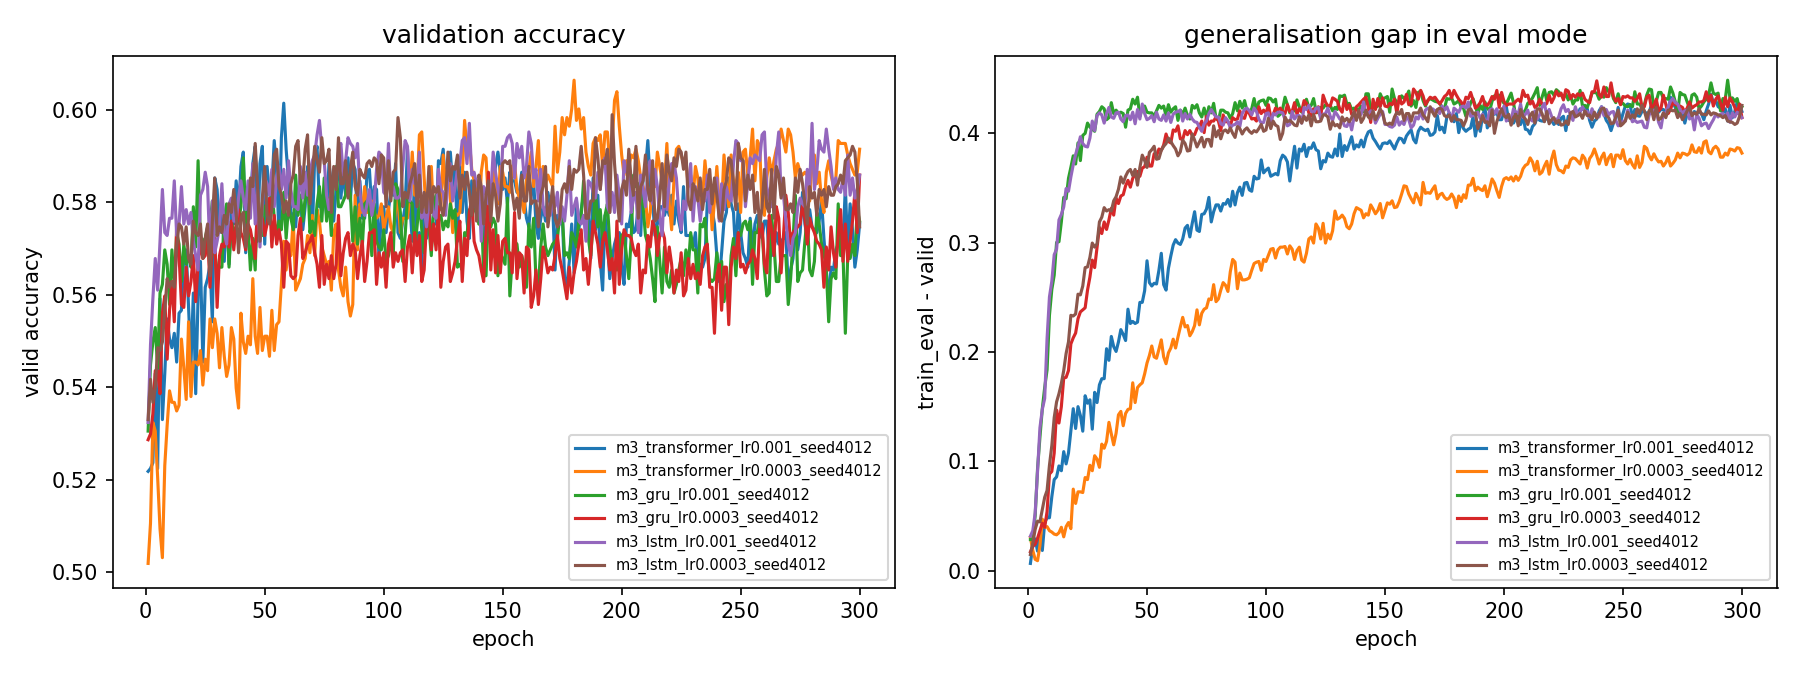

In [17]:
curves = OUT_DIR / 'm3_curves.png'
if curves.exists():
    display(Image(filename=str(curves)))

## 6 · Download

In [18]:
import shutil
archive = shutil.make_archive('/content/e1_stress_results', 'zip', OUT_DIR)
print(archive, round(Path(archive).stat().st_size / 1e6, 1), "MB")

from google.colab import files
files.download(archive)

/content/e1_stress_results.zip 25.3 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>